# Plant Disease Detector – Weeks 6–7

## Per-Class Disease Evaluation

In Weeks 6–7, the trained CNN model from Week 5 is evaluated separately for each plant disease class.

### Objectives

- Load the trained CNN model
- Load the PlantVillage validation dataset
- Generate predictions for validation images
- Calculate accuracy for each disease class
- Generate a classification report
- Create a confusion matrix
- Analyze the model's performance for individual diseases

In [1]:
import tensorflow as tf
import numpy as np
import os

# Load the trained model from Week 5
model_path = r"C:\Users\SARVAJEETH\OneDrive\Desktop\edp weeks\edpweek5\plant_disease_cnn.keras"

model = tf.keras.models.load_model(model_path)

print("Model loaded successfully!")
print("Model input shape:", model.input_shape)
print("Number of output classes:", model.output_shape[-1])





Model loaded successfully!
Model input shape: (None, 224, 224, 3)
Number of output classes: 15


In [5]:
# Path to the PlantVillage dataset
data_dir = r"C:\Users\SARVAJEETH\OneDrive\Desktop\edp weeks\dataset\PlantVillage\PlantVillage"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load the validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

class_names = val_ds.class_names

print("Validation dataset loaded successfully!")
print("Number of classes:", len(class_names))
print("Number of validation batches:", len(val_ds))
print("Classes:")
print(class_names)

Found 20637 files belonging to 15 classes.
Using 4127 files for validation.
Validation dataset loaded successfully!
Number of classes: 15
Number of validation batches: 129
Classes:
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [7]:
# Generate predictions for all validation images

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated successfully!")
print("Total validation images:", len(y_true))
print("Total predictions:", len(y_pred))

Predictions generated successfully!
Total validation images: 4127
Total predictions: 4127


In [8]:
# Calculate accuracy for each disease class

print("Per-Class Accuracy")
print("=" * 60)

for i, class_name in enumerate(class_names):
    class_mask = (y_true == i)

    total = np.sum(class_mask)
    correct = np.sum(y_pred[class_mask] == i)

    accuracy = (correct / total) * 100

    print(f"{class_name:50s} : {accuracy:.2f}%")

Per-Class Accuracy
Pepper__bell___Bacterial_spot                      : 76.14%
Pepper__bell___healthy                             : 97.86%
Potato___Early_blight                              : 97.94%
Potato___Late_blight                               : 82.59%
Potato___healthy                                   : 46.43%
Tomato_Bacterial_spot                              : 94.94%
Tomato_Early_blight                                : 60.00%
Tomato_Late_blight                                 : 85.60%
Tomato_Leaf_Mold                                   : 81.34%
Tomato_Septoria_leaf_spot                          : 84.87%
Tomato_Spider_mites_Two_spotted_spider_mite        : 95.00%
Tomato__Target_Spot                                : 77.11%
Tomato__Tomato_YellowLeaf__Curl_Virus              : 94.96%
Tomato__Tomato_mosaic_virus                        : 98.67%
Tomato_healthy                                     : 96.20%


In [10]:
from sklearn.metrics import classification_report

# Generate detailed classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("Classification Report")
print("=" * 80)
print(report)

Classification Report
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot     0.9437    0.7614    0.8428       176
                     Pepper__bell___healthy     0.8562    0.9786    0.9133       280
                      Potato___Early_blight     0.8482    0.9794    0.9091       194
                       Potato___Late_blight     0.8894    0.8259    0.8565       224
                           Potato___healthy     1.0000    0.4643    0.6341        28
                      Tomato_Bacterial_spot     0.9563    0.9494    0.9528       415
                        Tomato_Early_blight     0.7843    0.6000    0.6799       200
                         Tomato_Late_blight     0.8015    0.8560    0.8279       368
                           Tomato_Leaf_Mold     0.9091    0.8134    0.8586       209
                  Tomato_Septoria_leaf_spot     0.8242    0.8487    0.8363       337
Tomato_Spider_mites_Two_spotted_spider_mit

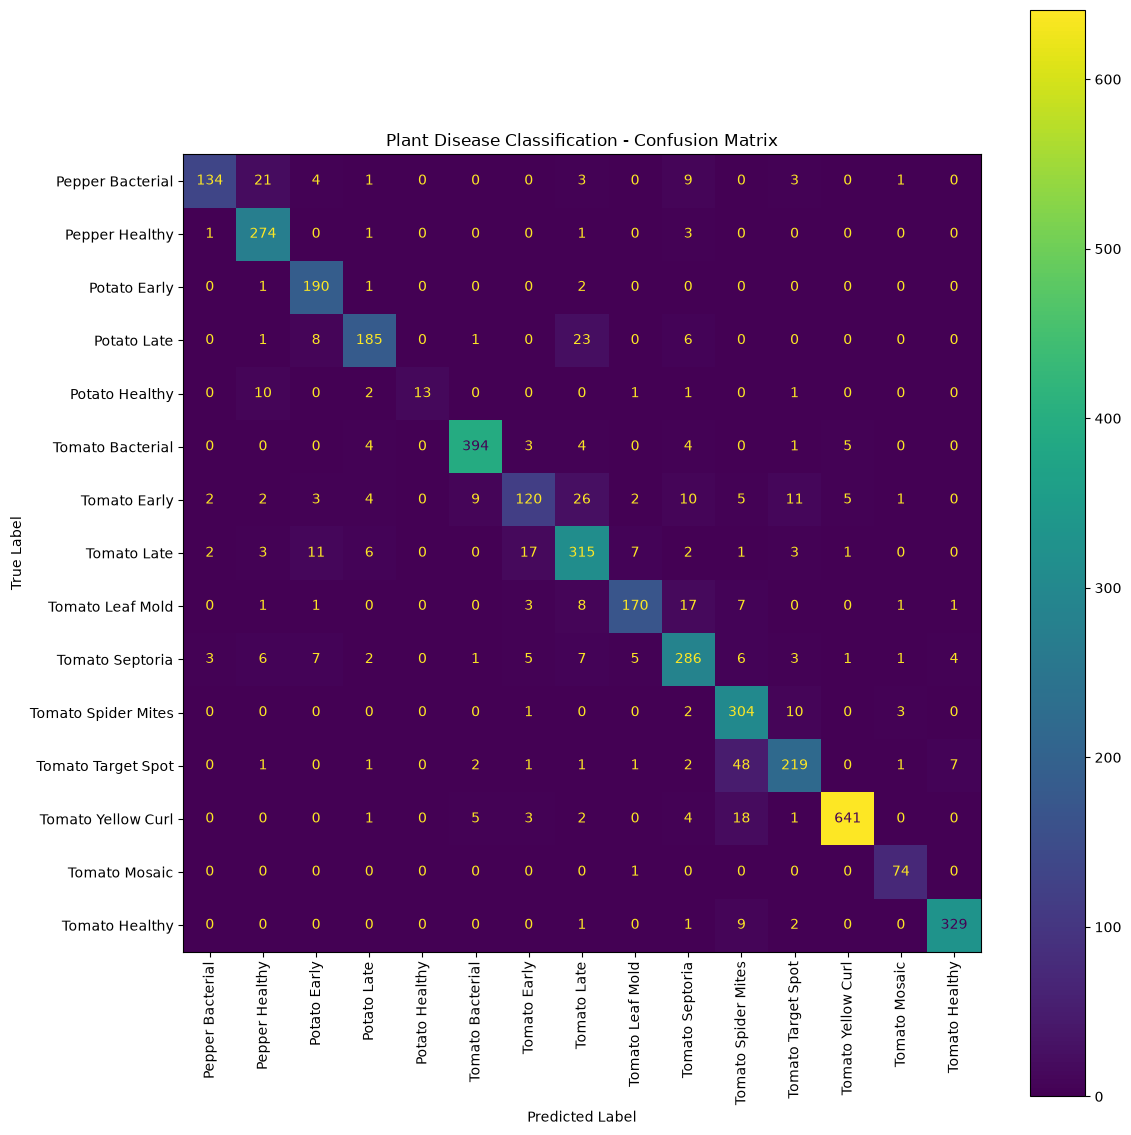

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Short names for better visualization
short_names = [
    "Pepper Bacterial",
    "Pepper Healthy",
    "Potato Early",
    "Potato Late",
    "Potato Healthy",
    "Tomato Bacterial",
    "Tomato Early",
    "Tomato Late",
    "Tomato Leaf Mold",
    "Tomato Septoria",
    "Tomato Spider Mites",
    "Tomato Target Spot",
    "Tomato Yellow Curl",
    "Tomato Mosaic",
    "Tomato Healthy"
]

# Create confusion matrix display
fig, ax = plt.subplots(figsize=(12, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=short_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)

ax.set_title("Plant Disease Classification - Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

## Results Summary

The trained CNN model was evaluated on the PlantVillage validation dataset containing 4,127 images across 15 plant disease classes.

### Overall Performance

- Total validation images: 4,127
- Number of classes: 15
- Validation Accuracy: 88.39%

### Evaluation Performed

- Per-class accuracy analysis
- Precision, recall, and F1-score analysis
- Confusion matrix analysis

### Conclusion

The CNN model successfully classified plant diseases across the 15 PlantVillage classes. The per-class evaluation shows that the model performs well for most disease categories, while some classes such as Potato Healthy and Tomato Early Blight have lower accuracy and could be improved with additional training data, data augmentation, or model optimization.

The confusion matrix provides a detailed view of correct and incorrect predictions for each plant disease class.